In [1]:
import matplotlib.pyplot as plt
from sklearn import datasets , svm , metrics
import numpy as np

In [2]:
# Chargement d’un jeu de données préconçu
digits = datasets.load_digits()

In [3]:
# On peut afficher le contenu de digits - Toutes les images (en brut)
print(digits.images)

[[[ 0.  0.  5. ...  1.  0.  0.]
  [ 0.  0. 13. ... 15.  5.  0.]
  [ 0.  3. 15. ... 11.  8.  0.]
  ...
  [ 0.  4. 11. ... 12.  7.  0.]
  [ 0.  2. 14. ... 12.  0.  0.]
  [ 0.  0.  6. ...  0.  0.  0.]]

 [[ 0.  0.  0. ...  5.  0.  0.]
  [ 0.  0.  0. ...  9.  0.  0.]
  [ 0.  0.  3. ...  6.  0.  0.]
  ...
  [ 0.  0.  1. ...  6.  0.  0.]
  [ 0.  0.  1. ...  6.  0.  0.]
  [ 0.  0.  0. ... 10.  0.  0.]]

 [[ 0.  0.  0. ... 12.  0.  0.]
  [ 0.  0.  3. ... 14.  0.  0.]
  [ 0.  0.  8. ... 16.  0.  0.]
  ...
  [ 0.  9. 16. ...  0.  0.  0.]
  [ 0.  3. 13. ... 11.  5.  0.]
  [ 0.  0.  0. ... 16.  9.  0.]]

 ...

 [[ 0.  0.  1. ...  1.  0.  0.]
  [ 0.  0. 13. ...  2.  1.  0.]
  [ 0.  0. 16. ... 16.  5.  0.]
  ...
  [ 0.  0. 16. ... 15.  0.  0.]
  [ 0.  0. 15. ... 16.  0.  0.]
  [ 0.  0.  2. ...  6.  0.  0.]]

 [[ 0.  0.  2. ...  0.  0.  0.]
  [ 0.  0. 14. ... 15.  1.  0.]
  [ 0.  4. 16. ... 16.  7.  0.]
  ...
  [ 0.  0.  0. ... 16.  2.  0.]
  [ 0.  0.  4. ... 16.  2.  0.]
  [ 0.  0.  5. ... 12.  0.  

In [4]:
for i in range (4):
    print(digits.images[i])

[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
[[ 0.  0.  0. 12. 13.  5.  0.  0.]
 [ 0.  0.  0. 11. 16.  9.  0.  0.]
 [ 0.  0.  3. 15. 16.  6.  0.  0.]
 [ 0.  7. 15. 16. 16.  2.  0.  0.]
 [ 0.  0.  1. 16. 16.  3.  0.  0.]
 [ 0.  0.  1. 16. 16.  6.  0.  0.]
 [ 0.  0.  1. 16. 16.  6.  0.  0.]
 [ 0.  0.  0. 11. 16. 10.  0.  0.]]
[[ 0.  0.  0.  4. 15. 12.  0.  0.]
 [ 0.  0.  3. 16. 15. 14.  0.  0.]
 [ 0.  0.  8. 13.  8. 16.  0.  0.]
 [ 0.  0.  1.  6. 15. 11.  0.  0.]
 [ 0.  1.  8. 13. 15.  1.  0.  0.]
 [ 0.  9. 16. 16.  5.  0.  0.  0.]
 [ 0.  3. 13. 16. 16. 11.  5.  0.]
 [ 0.  0.  0.  3. 11. 16.  9.  0.]]
[[ 0.  0.  7. 15. 13.  1.  0.  0.]
 [ 0.  8. 13.  6. 15.  4.  0.  0.]
 [ 0.  2.  1. 13. 13.  0.  0.  0.]
 [ 0.  0.  2. 15. 11.  1.  0.  0.]
 [ 0.  0.  0.  1.

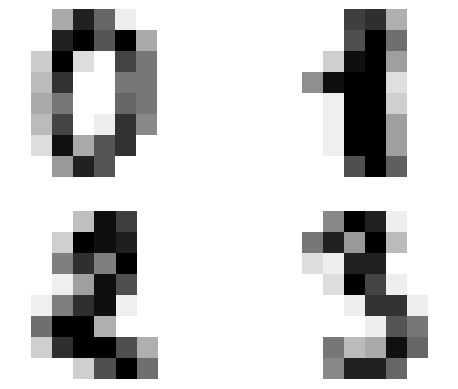

In [5]:
# Pour afficher les 4 premières images

for i in range( 4):
    plt.subplot(2, 2, i+1)
    plt.axis('off')
    plt.imshow(digits.images[i], cmap=plt.cm.gray_r , interpolation='nearest')
    
plt.show()

In [6]:
# Exo 1 Poser un % des données associées à l’apprentissage (par exemple, 50%)
n_samples = len(digits.images)

# Suivant ce ratio, séparer les données brutes en
# Données apprentissage : data_learning 
X = digits.data[: n_samples // 2 ]
y = digits.target[: n_samples // 2 ]
# Données test : data_test
X_test = digits.data[n_samples // 2 :]
y_test = digits.target[n_samples // 2 :]

# Même chose pour les labels
# Labels apprentissage : labels_learning
labels_learning = y
# Labels test : labels_test
labels_test = y_test

# Créer un classifieur de type SVM : classifier
# Noyau RBF - paramettre de votre choix 
classifier = svm.SVC(gamma=0.001)

#apprentissage sur les données brutes data_learning / labels_learnings
classifier.fit(X, y)

#lancer la prédiction sur data_test 
prediction = classifier.predict(X_test)


In [7]:
#Pour afficher les statistiques :
print("\nreport for classifier %s:\n%s\n" %
      (classifier,
       metrics.classification_report(labels_test, prediction)))


report for classifier SVC(gamma=0.001):
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        88
           1       0.99      0.97      0.98        91
           2       0.99      0.99      0.99        86
           3       0.98      0.87      0.92        91
           4       0.99      0.96      0.97        92
           5       0.95      0.97      0.96        91
           6       0.99      0.99      0.99        91
           7       0.96      0.99      0.97        89
           8       0.94      1.00      0.97        88
           9       0.93      0.98      0.95        92

    accuracy                           0.97       899
   macro avg       0.97      0.97      0.97       899
weighted avg       0.97      0.97      0.97       899




In [8]:
#Pour afficher la matrice de confusion 
print("\nconfusion matrix:\n%s" %
      metrics.confusion_matrix(labels_test, prediction))


confusion matrix:
[[87  0  0  0  1  0  0  0  0  0]
 [ 0 88  1  0  0  0  0  0  1  1]
 [ 0  0 85  1  0  0  0  0  0  0]
 [ 0  0  0 79  0  3  0  4  5  0]
 [ 0  0  0  0 88  0  0  0  0  4]
 [ 0  0  0  0  0 88  1  0  0  2]
 [ 0  1  0  0  0  0 90  0  0  0]
 [ 0  0  0  0  0  1  0 88  0  0]
 [ 0  0  0  0  0  0  0  0 88  0]
 [ 0  0  0  1  0  1  0  0  0 90]]


In [9]:
#Pour comparer, on peut mettre en place un RNA 
# MLP : Multi-layer perception 
# Exo 2 En utilisant vos connaissances et la documentation, identifier les paramètres du MLP
from sklearn.neural_network import MLPClassifier
# ...
classifier_mlp = MLPClassifier(hidden_layer_sizes=(15,),  # nombre de neurones par couche cachée
                               activation='logistic', # activation => logistic est une fonction sigmoïde returns f(x) = 1 / (1 + exp(-x))
                               alpha=1e-4,  # paramètre de régularisation
                               solver='sgd', # pour l'optimisation du poids - ici utilise la descente de gradient stochastique 
                               tol=1e-4, # tolérance pour l'arrêt de l'apprentissage
                               random_state=1, # détermine la génération de nombres aléatoires pour l'initialisation des poids et des biais
                               learning_rate_init=.1, # taux d'apprentissage initial
                               verbose=True) # pour afficher des informations durant l'apprentissage